# Init

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="0"



In [2]:
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_int8_training,
)
from peft import PeftModel

In [3]:

import sys
import itertools
from tqdm.auto import tqdm
import pathlib
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

import datasets
from contextlib import nullcontext
import torch
from torch import nn
from transformers import (
    Trainer,
    TrainingArguments,
    LlamaTokenizer,
    LlamaForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)


import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

from safetensors import safe_open

# Load LoRA adapters

In [4]:
### SHAC
target_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/set-11063-quantization-epoch3-llama-2-7B-loraR-8"
source_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/Source-set-11063-quantization-epoch3-llama-2-7B-loraR-8"
reverse_source_model_id = "/bime-munin/xiruod/llama2_SHAC/n200/Reverse-Source-set-11063-quantization-epoch3-llama-2-7B-loraR-8"

# target_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/set-6114-quantization-epoch3-llama-2-7B-loraR-8"
# source_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/Source-set-6114-quantization-epoch3-llama-2-7B-loraR-8"
# reverse_source_model_id = "/bime-munin/xiruod/llama2_SHAC/n200/Reverse-Source-set-6114-quantization-epoch3-llama-2-7B-loraR-8"

# target_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/set-1152-quantization-epoch3-llama-2-7B-loraR-8"
# source_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/Source-set-1152-quantization-epoch3-llama-2-7B-loraR-8"
# reverse_source_model_id = "/bime-munin/xiruod/llama2_SHAC/n200/Reverse-Source-set-1152-quantization-epoch3-llama-2-7B-loraR-8"



### HateSpeech
# target_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/set-9870-quantization-epoch3-llama-2-7B-loraR-8"
# source_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/Source-set-9870-quantization-epoch3-llama-2-7B-loraR-8"
# reverse_source_model_id = "/bime-munin/xiruod/llama2_HateSpeech/n1000/Reverse-Source-set-9870-quantization-epoch3-llama-2-7B-loraR-8"

# target_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/set-6126-quantization-epoch3-llama-2-7B-loraR-8"
# source_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/Source-set-6126-quantization-epoch3-llama-2-7B-loraR-8"
# reverse_source_model_id = "/bime-munin/xiruod/llama2_HateSpeech/n1000/Reverse-Source-set-6126-quantization-epoch3-llama-2-7B-loraR-8"

# target_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/set-1874-quantization-epoch3-llama-2-7B-loraR-8"
# source_model_id =         "/bime-munin/xiruod/llama2_HateSpeech/n1000/Source-set-1874-quantization-epoch3-llama-2-7B-loraR-8"
# reverse_source_model_id = "/bime-munin/xiruod/llama2_HateSpeech/n1000/Reverse-Source-set-1874-quantization-epoch3-llama-2-7B-loraR-8"

In [5]:
target_tensors = {}
source_tensors = {}
reverse_source_tensors = {}

with safe_open(f"{target_model_id}/adapter_model.safetensors", framework="pt", device="cpu") as f:
    for key in f.keys():
        target_tensors[key] = f.get_tensor(key)
        
with safe_open(f"{source_model_id}/adapter_model.safetensors", framework="pt", device="cpu") as f:
    for key in f.keys():
        source_tensors[key] = f.get_tensor(key)
            

with safe_open(f"{reverse_source_model_id}/adapter_model.safetensors", framework="pt", device="cpu") as f:
    for key in f.keys():
        reverse_source_tensors[key] = f.get_tensor(key)
        

In [6]:
assert set(target_tensors.keys()) == set(source_tensors.keys()) == set(reverse_source_tensors.keys())
lora_adapter_keys = list(source_tensors.keys())

# Check Similarity for A, B Separately

In [7]:
def tensorCosine(A,B):
    return torch.trace(torch.matmul(A, B.T))/torch.sqrt(torch.trace(torch.matmul(A,A.T)) * torch.trace(torch.matmul(B,B.T)))
    

In [8]:
layer_levels = [str(x) for x in range(32)] + ['cls']

In [9]:
matrix_sims = {}


for k in lora_adapter_keys:
    matrix_sims[k] = []
    matrix_sims[k].append(tensorCosine(source_tensors[k], reverse_source_tensors[k]).numpy().item()) # SR
    matrix_sims[k].append(tensorCosine(target_tensors[k], source_tensors[k]).numpy().item()) # TS
    matrix_sims[k].append(tensorCosine(target_tensors[k], reverse_source_tensors[k]).numpy().item()) # TR
    

In [10]:
df_loras = pd.DataFrame(matrix_sims).T.reset_index()
df_loras.columns = ['layerID','cosSim-SR','cosSim-TS','cosSim-TR']

In [11]:
df_loras['layer'] = df_loras['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score.weight' else "cls")
df_loras['layer'] = pd.Categorical(df_loras['layer'], categories=layer_levels)

In [12]:
df_loras['loraProj'] = df_loras['layerID'].apply(lambda x: x.split(".")[-3] if x != 'base_model.model.score.weight' else "cls")
df_loras['loraMatrix'] = df_loras['layerID'].apply(lambda x: x.split(".")[-2] if x != 'base_model.model.score.weight' else "cls")

In [13]:
matrix_norms = {}


for k in lora_adapter_keys:
    matrix_norms[k] = []
    matrix_norms[k].append(torch.norm(target_tensors[k], p='fro').item())
    matrix_norms[k].append(torch.norm(source_tensors[k], p='fro').item())
    matrix_norms[k].append(torch.norm(reverse_source_tensors[k], p='fro').item())

    

In [14]:
df_loras_norms = pd.DataFrame(matrix_norms).T.reset_index()
df_loras_norms.columns = ['layerID','norm-T','norm-S','norm-RS']

In [15]:
df_loras_norms['layer'] = df_loras_norms['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score.weight' else "cls")
df_loras_norms['layer'] = pd.Categorical(df_loras_norms['layer'], categories=layer_levels)

In [16]:
df_loras_norms['loraProj'] = df_loras_norms['layerID'].apply(lambda x: x.split(".")[-3] if x != 'base_model.model.score.weight' else "cls")
df_loras_norms['loraMatrix'] = df_loras_norms['layerID'].apply(lambda x: x.split(".")[-2] if x != 'base_model.model.score.weight' else "cls")

# Check Similairty for A*B

In [17]:
lora_merged_keys = set([x.split(".weight")[0].replace(".lora_A","").replace(".lora_B","") for x in lora_adapter_keys])

In [18]:
len(lora_merged_keys)

65

In [19]:
merged_matrix_sims = {}

for k in lora_merged_keys:
    merged_matrix_sims[k] = []
    if k != "base_model.model.score":
        
        A_t = target_tensors[f"{k}.lora_A.weight"]
        B_t = target_tensors[f"{k}.lora_B.weight"]
        
        A_s = source_tensors[f"{k}.lora_A.weight"]
        B_s = source_tensors[f"{k}.lora_B.weight"]

        A_rs = reverse_source_tensors[f"{k}.lora_A.weight"]
        B_rs = reverse_source_tensors[f"{k}.lora_B.weight"]
    
        merged_matrix_sims[k].append(tensorCosine(torch.matmul(B_s, A_s), torch.matmul(B_rs, A_rs)).numpy().item()) # SR
        merged_matrix_sims[k].append(tensorCosine(torch.matmul(B_t, A_t), torch.matmul(B_s, A_s)).numpy().item()) # TS
        merged_matrix_sims[k].append(tensorCosine(torch.matmul(B_t, A_t), torch.matmul(B_rs, A_rs)).numpy().item()) # TR
        
        
    else:
        
        merged_matrix_sims[k].append(tensorCosine(source_tensors[f"{k}.weight"], reverse_source_tensors[f"{k}.weight"]).numpy().item()) # SR
        merged_matrix_sims[k].append(tensorCosine(target_tensors[f"{k}.weight"], source_tensors[f"{k}.weight"]).numpy().item()) # TS
        merged_matrix_sims[k].append(tensorCosine(target_tensors[f"{k}.weight"], reverse_source_tensors[f"{k}.weight"]).numpy().item()) # TR
        

In [20]:
df_merged = pd.DataFrame(merged_matrix_sims).T.reset_index()
df_merged.columns = ['layerID','cosSim-SR','cosSim-TS','cosSim-TR']

In [21]:
df_merged['layer'] = df_merged['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score' else "cls")
df_merged['layer'] = pd.Categorical(df_merged['layer'], categories=layer_levels)

In [22]:
df_merged['loraProj'] = df_merged['layerID'].apply(lambda x: x.split(".")[-1] if x != 'base_model.model.score' else "cls")

In [23]:
merged_matrix_norms = {}

for k in lora_merged_keys:
    merged_matrix_norms[k] = []
    if k != "base_model.model.score":
        
        A_t = target_tensors[f"{k}.lora_A.weight"]
        B_t = target_tensors[f"{k}.lora_B.weight"]
        
        A_s = source_tensors[f"{k}.lora_A.weight"]
        B_s = source_tensors[f"{k}.lora_B.weight"]

        A_rs = reverse_source_tensors[f"{k}.lora_A.weight"]
        B_rs = reverse_source_tensors[f"{k}.lora_B.weight"]
    
        merged_matrix_norms[k].append(torch.norm(torch.matmul(B_t, A_t), p='fro').item())
        merged_matrix_norms[k].append(torch.norm(torch.matmul(B_s, A_s), p='fro').item())
        merged_matrix_norms[k].append(torch.norm(torch.matmul(B_rs, A_rs), p='fro').item())
        
        
    else:
        merged_matrix_norms[k].append(torch.norm(target_tensors[f"{k}.weight"], p='fro').item())
        merged_matrix_norms[k].append(torch.norm(source_tensors[f"{k}.weight"], p='fro').item())
        merged_matrix_norms[k].append(torch.norm(reverse_source_tensors[f"{k}.weight"], p='fro').item())


In [24]:
df_norms = pd.DataFrame(merged_matrix_norms).T.reset_index()
df_norms.columns = ['layerID','norm-T','norm-S','norm-RS']

In [25]:
df_norms['layer'] = df_norms['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score' else "cls")
df_norms['layer'] = pd.Categorical(df_norms['layer'], categories=layer_levels)

In [26]:
df_norms['loraProj'] = df_norms['layerID'].apply(lambda x: x.split(".")[-1] if x != 'base_model.model.score' else "cls")

# Visualize

## Similarities

In [27]:
plt.style.use('ggplot')

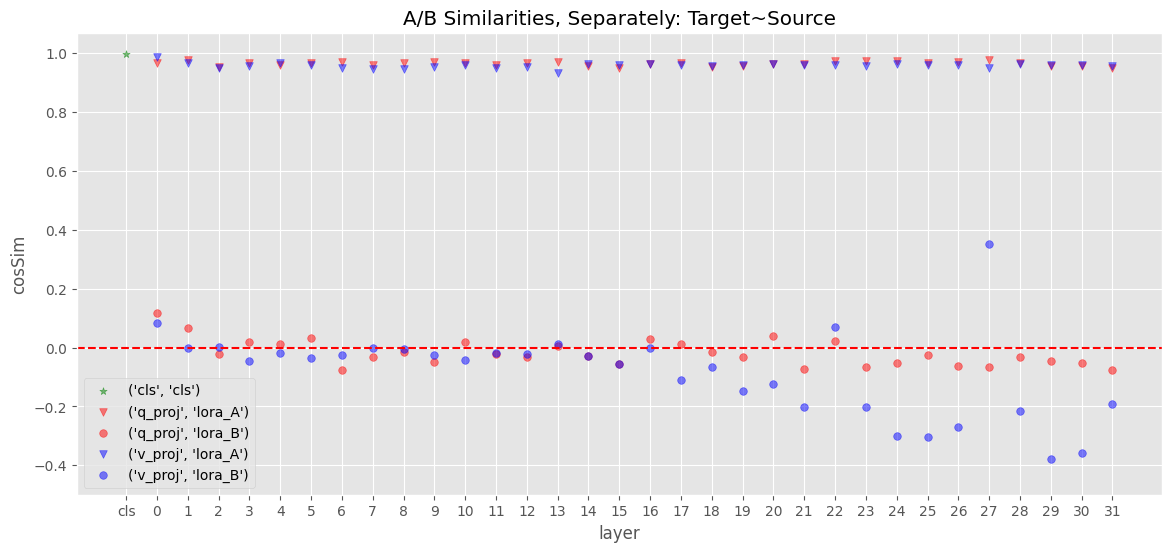

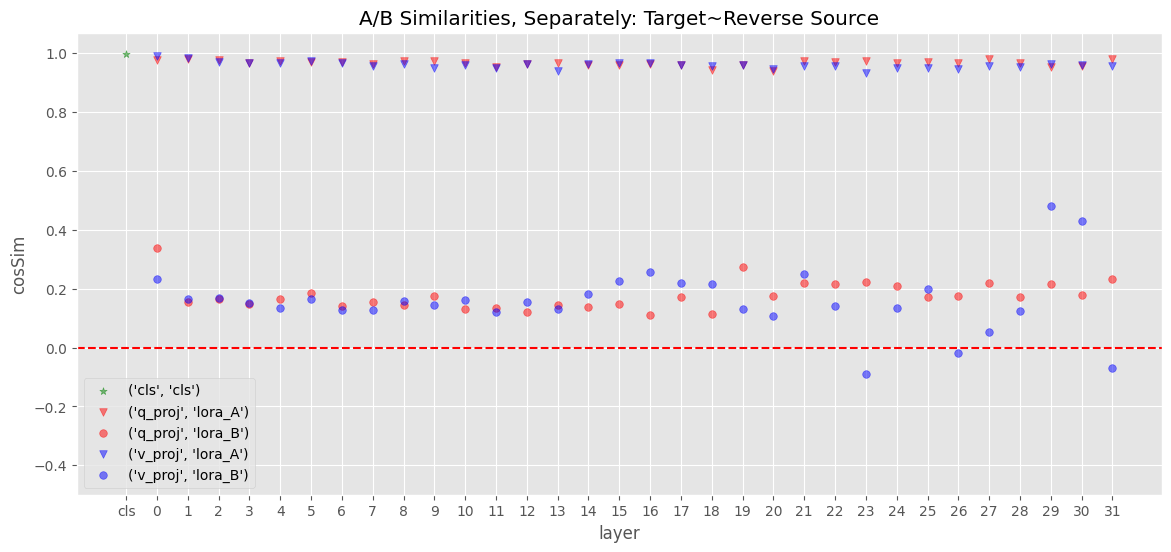

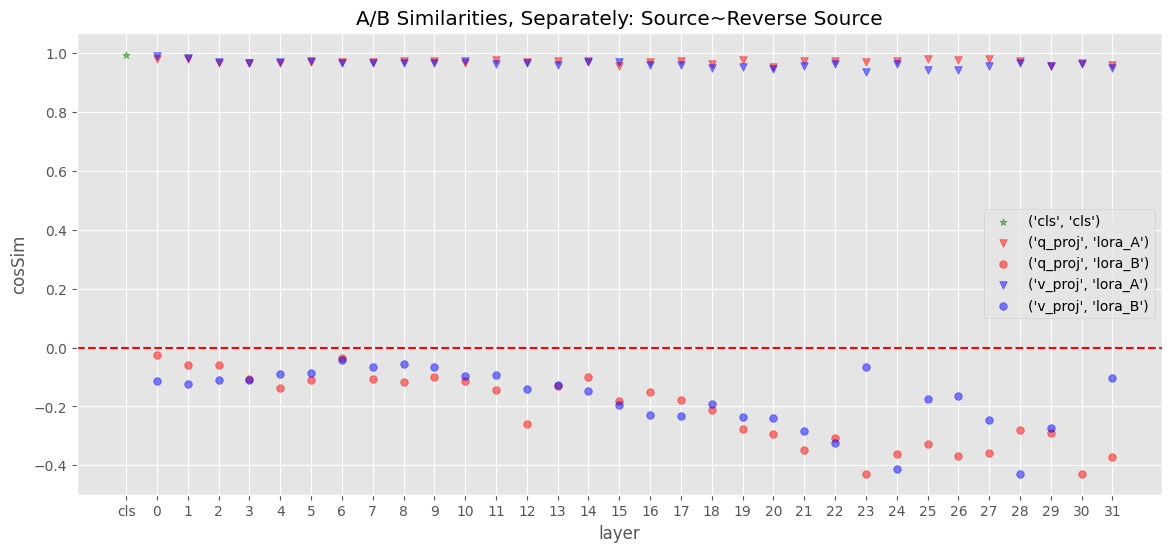

In [28]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
markdict={'lora_A':'v','lora_B':'o','cls':'*'}

# y_name = 'cosSim-TS'

for y_name in ['cosSim-TS', 'cosSim-TR', 'cosSim-SR']:
    grouped = df_loras.groupby(['loraProj','loraMatrix'])

    fig, ax = plt.subplots(figsize=(14, 6))


    for key, group in grouped:
        group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y=y_name, label=key, color=coldict[key[0]], marker=markdict[key[1]], alpha=0.5, s=30)
        # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

    plt.axhline(y=0, color='red', ls='--')
    plt.ylabel('cosSim')
    if y_name == "cosSim-TS":
        ylabname = "Target~Source"
    elif y_name == "cosSim-SR":
        ylabname = "Source~Reverse Source"
    elif y_name == "cosSim-TR":
        ylabname = "Target~Reverse Source"
    plt.title(f"A/B Similarities, Separately: {ylabname}")
    plt.ylim(-0.5,1.07)

    plt.show()


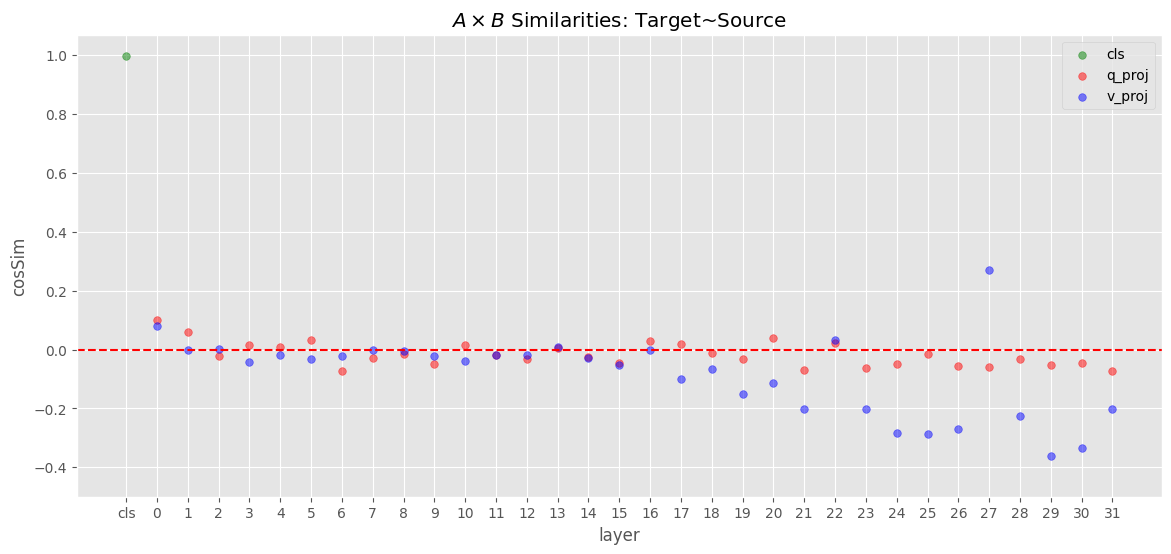

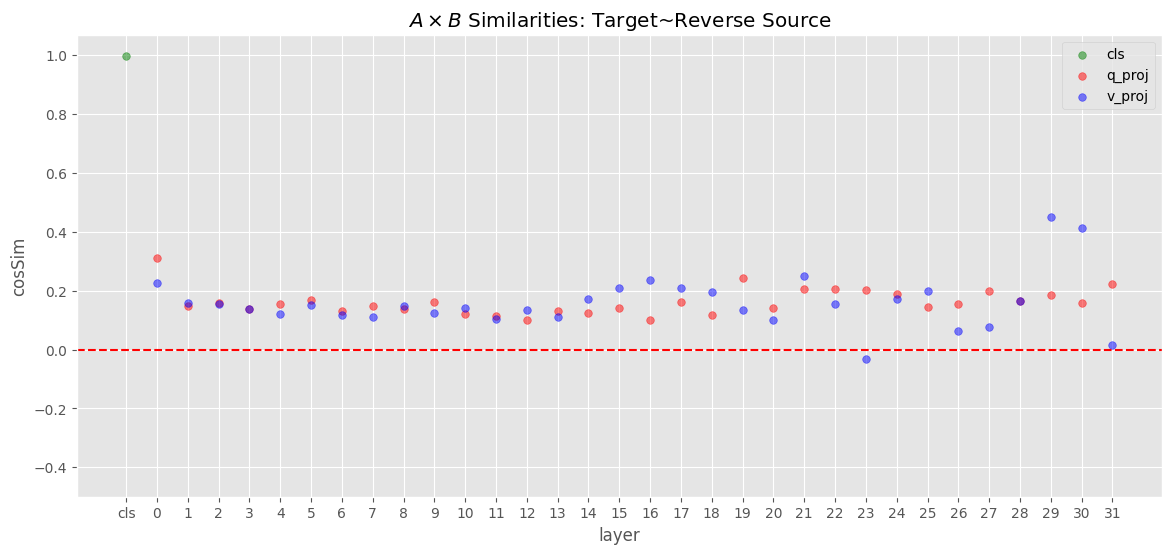

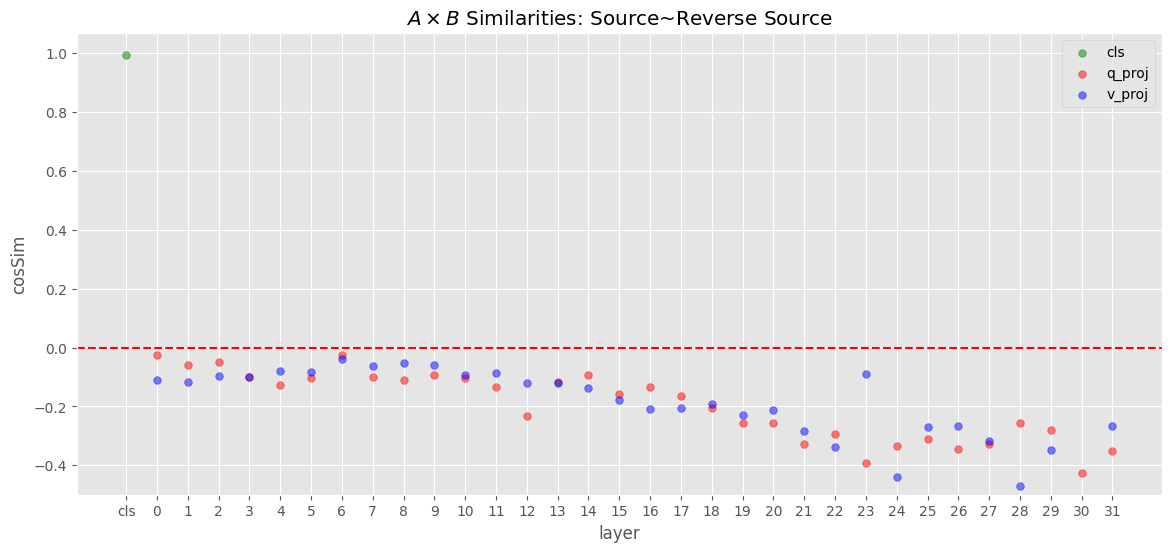

In [29]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
# markdict={'lora_A':'v','lora_B':'o','cls':'*'}

# y_name = 'cosSim-SR'

for y_name in ['cosSim-TS', 'cosSim-TR', 'cosSim-SR']:
    grouped = df_merged.groupby(['loraProj'])

    fig, ax = plt.subplots(figsize=(14, 6))


    for key, group in grouped:
        group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y=y_name, label=key[0], color=coldict[key[0]], 
                                        # marker=markdict[key[1]], 
                                        alpha=0.5, s=30)
        # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

    plt.axhline(y=0, color='red', ls='--')

    plt.ylabel('cosSim')
    if y_name == "cosSim-TS":
        ylabname = "Target~Source"
    elif y_name == "cosSim-SR":
        ylabname = "Source~Reverse Source"
    elif y_name == "cosSim-TR":
        ylabname = "Target~Reverse Source"

    plt.title(r"$A \times B$ Similarities: "+f"{ylabname}")
    plt.ylim(-0.5,1.07)


    plt.show()


## Norms

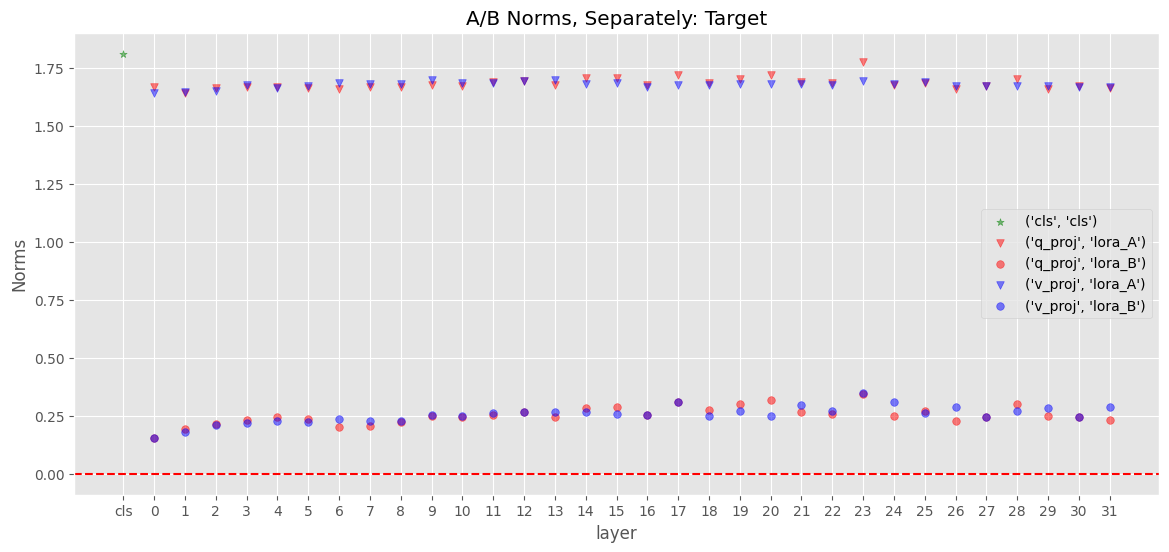

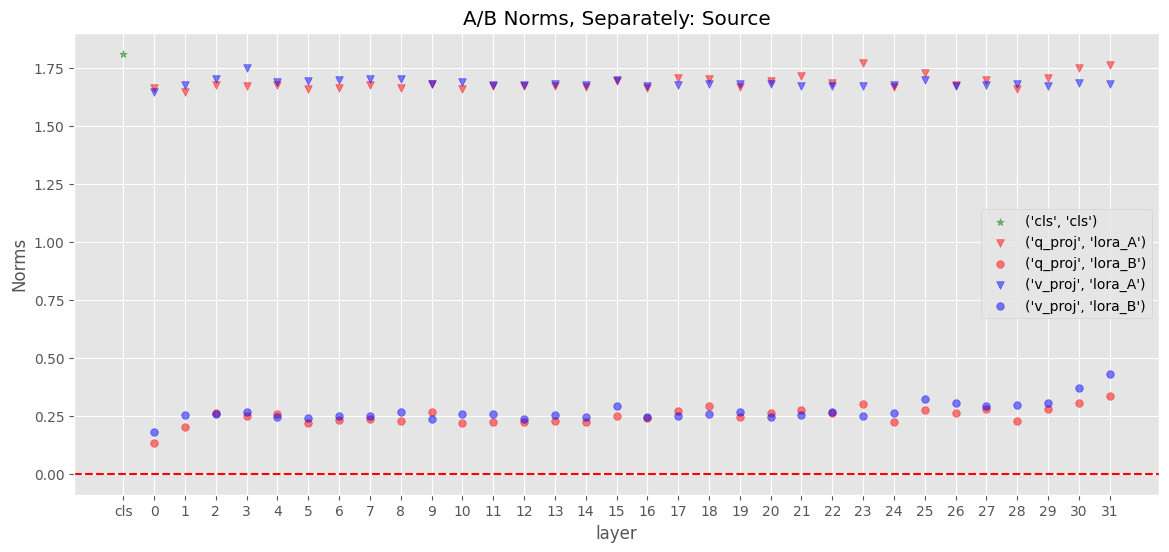

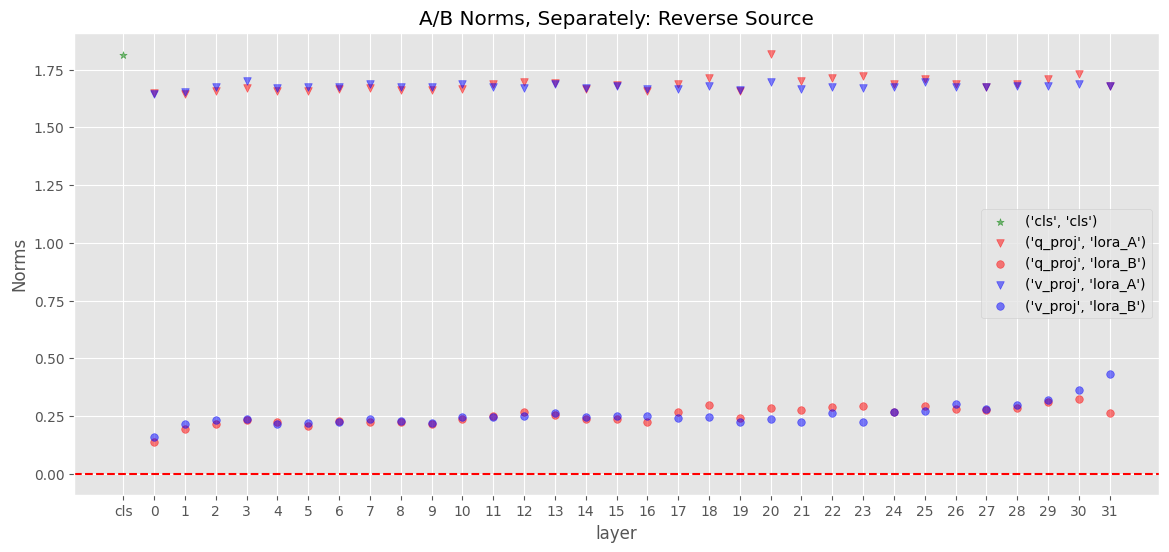

In [30]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
markdict={'lora_A':'v','lora_B':'o','cls':'*'}

for y_name in ['norm-T', 'norm-S', 'norm-RS']:
    grouped = df_loras_norms.groupby(['loraProj','loraMatrix'])

    fig, ax = plt.subplots(figsize=(14, 6))


    for key, group in grouped:
        group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y=y_name, label=key, color=coldict[key[0]], marker=markdict[key[1]], alpha=0.5, s=30)
        # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

    plt.axhline(y=0, color='red', ls='--')
    plt.ylabel('Norms')
    if y_name == "norm-T":
        ylabname = "Target"
    elif y_name == "norm-S":
        ylabname = "Source"
    elif y_name == "norm-RS":
        ylabname = "Reverse Source"

    plt.title(f"A/B Norms, Separately: {ylabname}")
    # plt.ylim(-0.05,2)

    plt.show()


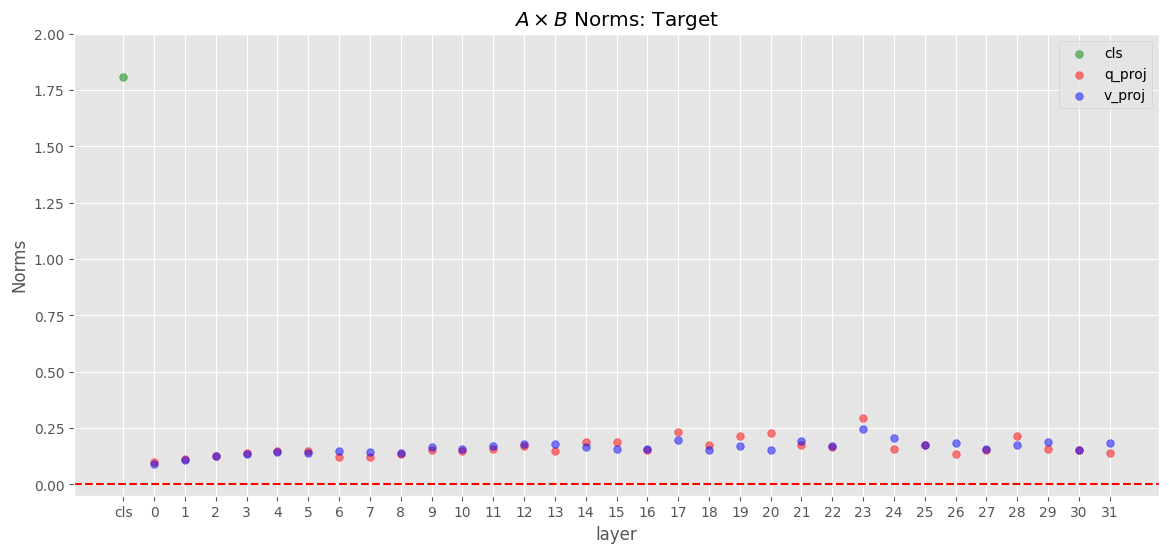

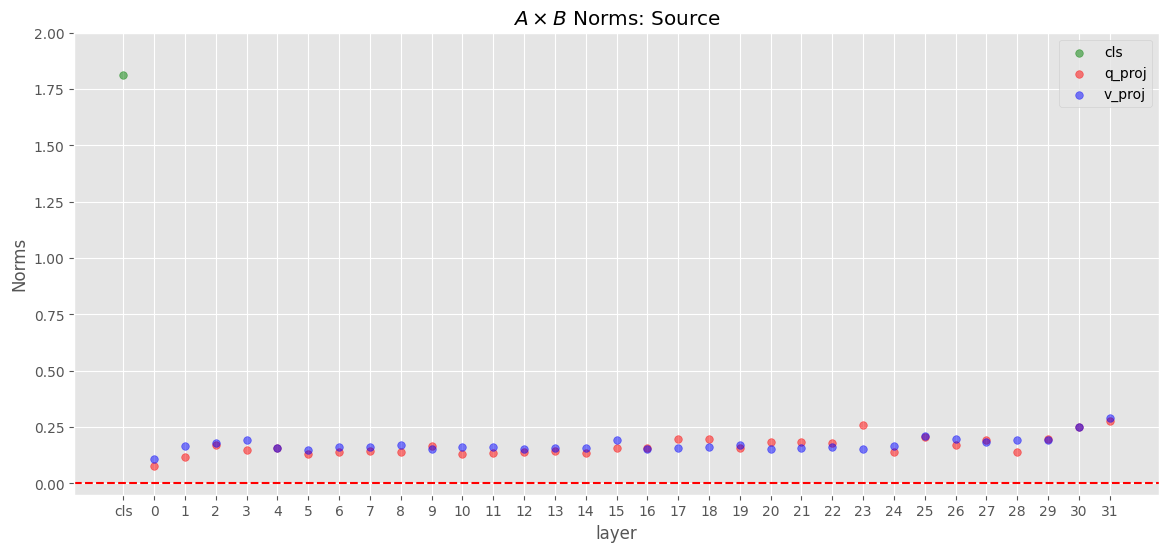

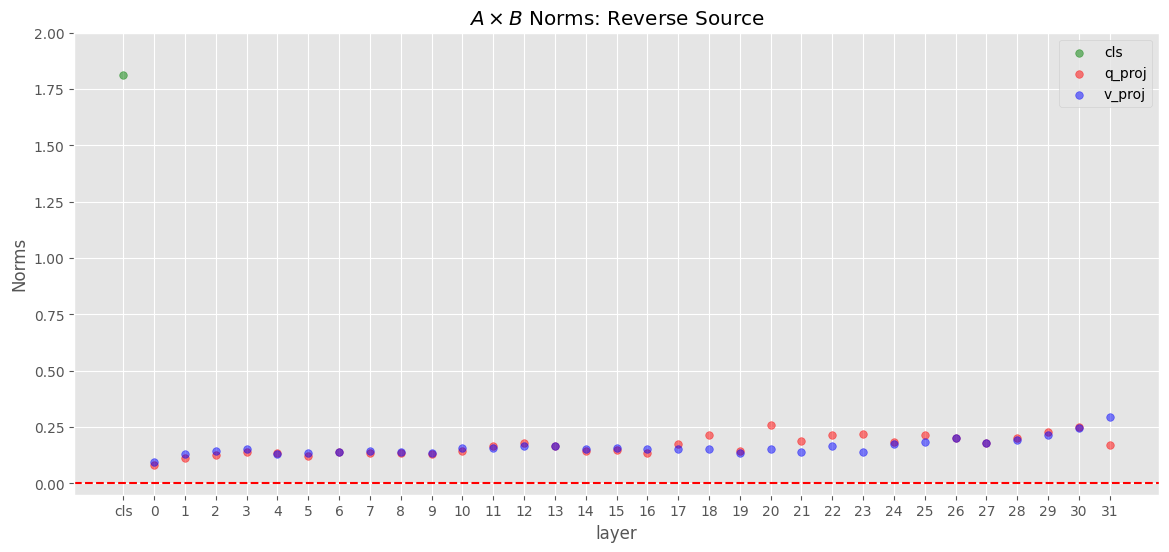

In [31]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
# markdict={'lora_A':'v','lora_B':'o','cls':'*'}

# y_name = 'cosSim-SR'

for y_name in ['norm-T', 'norm-S', 'norm-RS']:
    grouped = df_norms.groupby(['loraProj'])

    fig, ax = plt.subplots(figsize=(14, 6))


    for key, group in grouped:
        group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y=y_name, label=key[0], color=coldict[key[0]], 
                                        # marker=markdict[key[1]], 
                                        alpha=0.5, s=30)
        # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

    plt.axhline(y=0, color='red', ls='--')

    plt.ylabel('Norms')
    if y_name == "norm-T":
        ylabname = "Target"
    elif y_name == "norm-S":
        ylabname = "Source"
    elif y_name == "norm-RS":
        ylabname = "Reverse Source"

    plt.title(r"$A \times B$ Norms: "+f"{ylabname}")
    plt.ylim(-0.05,2)


    plt.show()


In [32]:
target_model_id

'/bime-munin/xiruod/llama2_SHAC/n200/set-11063-quantization-epoch3-llama-2-7B-loraR-8'

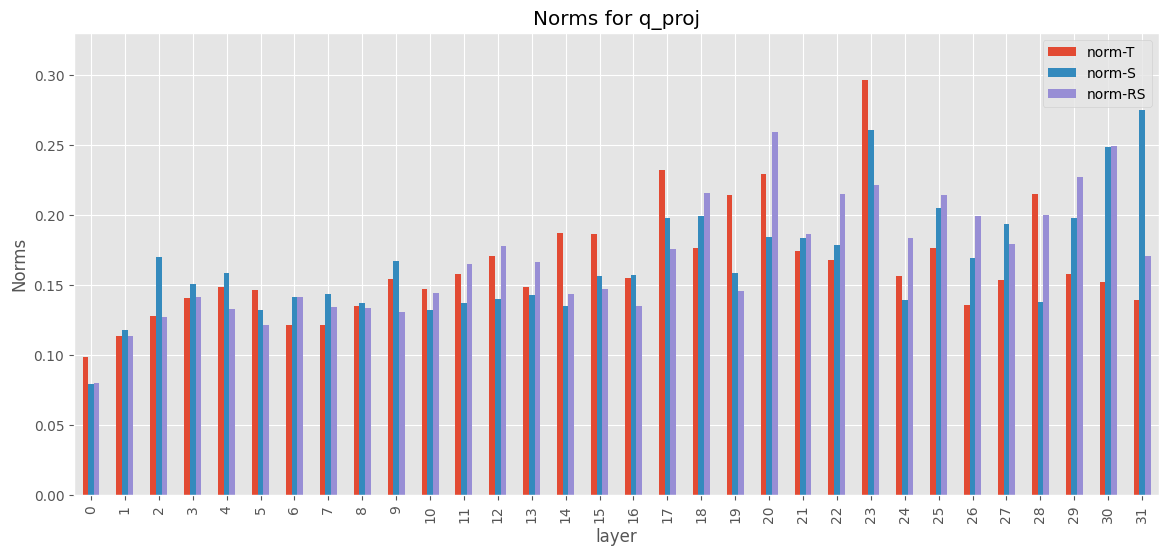

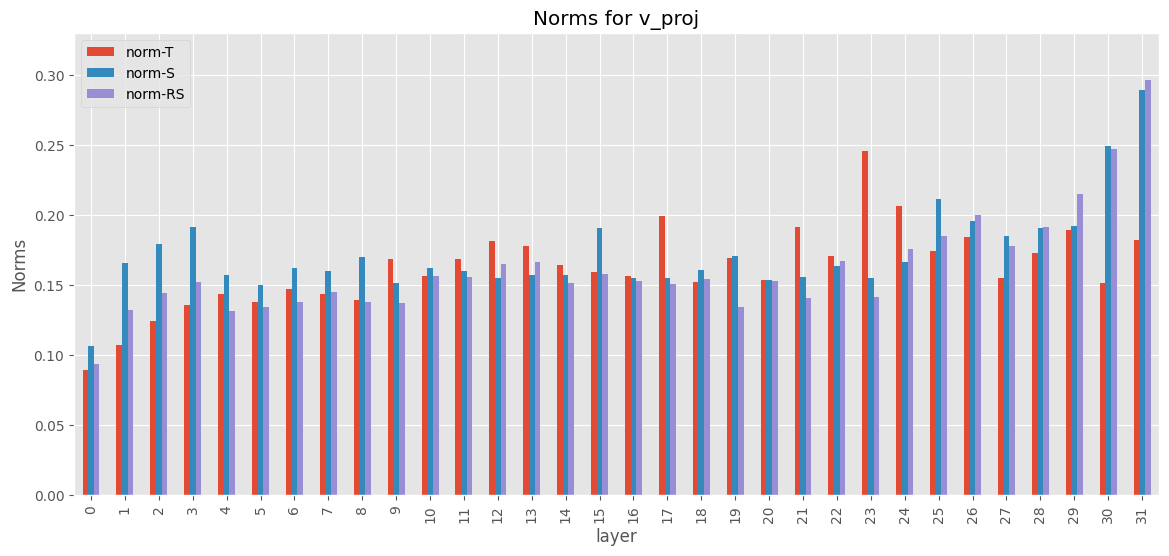

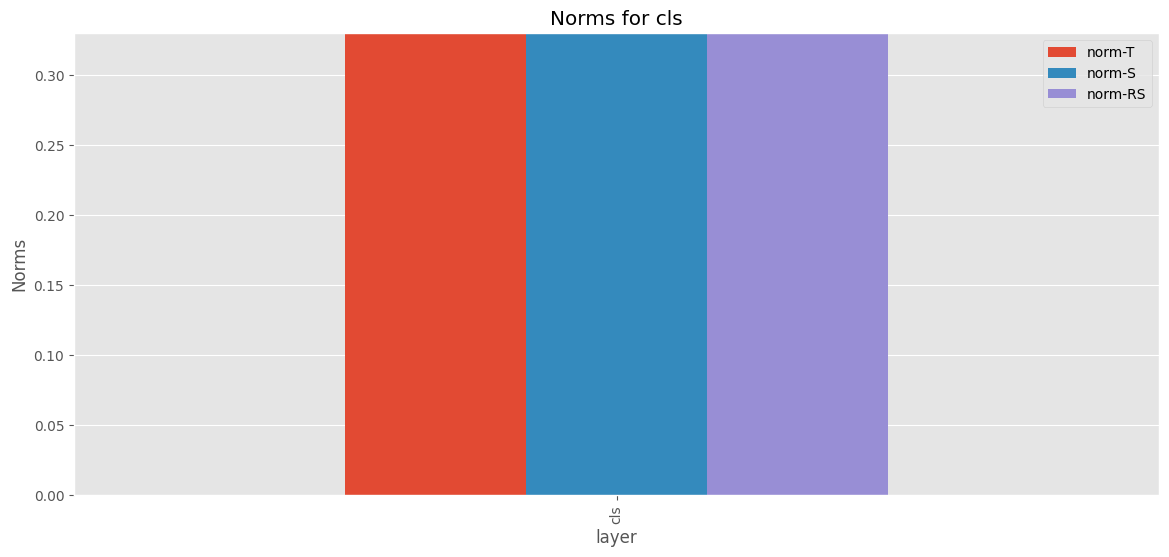

In [33]:

for k in ['q_proj','v_proj','cls']:
    fig, ax = plt.subplots(figsize=(14, 6))

    df_norms.query(f"loraProj == '{k}'").sort_values('layer').set_index('layer')[['norm-T','norm-S','norm-RS']].plot(ax=ax, kind='bar')
    plt.ylabel("Norms")
    plt.ylim(0,0.33)
    plt.title(f"Norms for {k}")
    plt.show()

In [34]:

df_norms.query(f"loraProj == 'cls'")[['norm-T','norm-S','norm-RS']].mean()

norm-T     1.809876
norm-S     1.811016
norm-RS    1.814554
dtype: float64

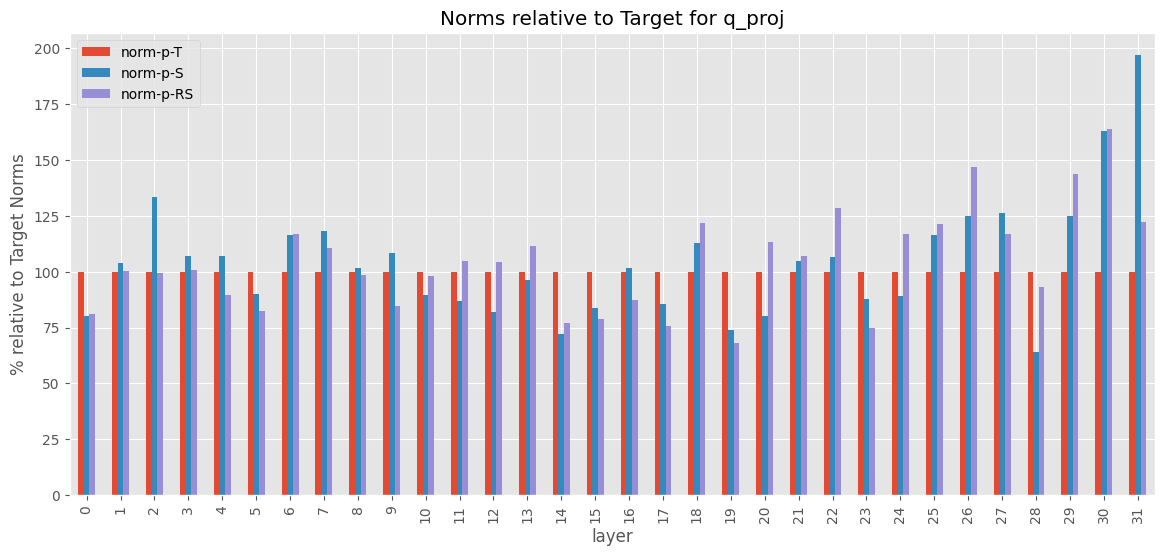

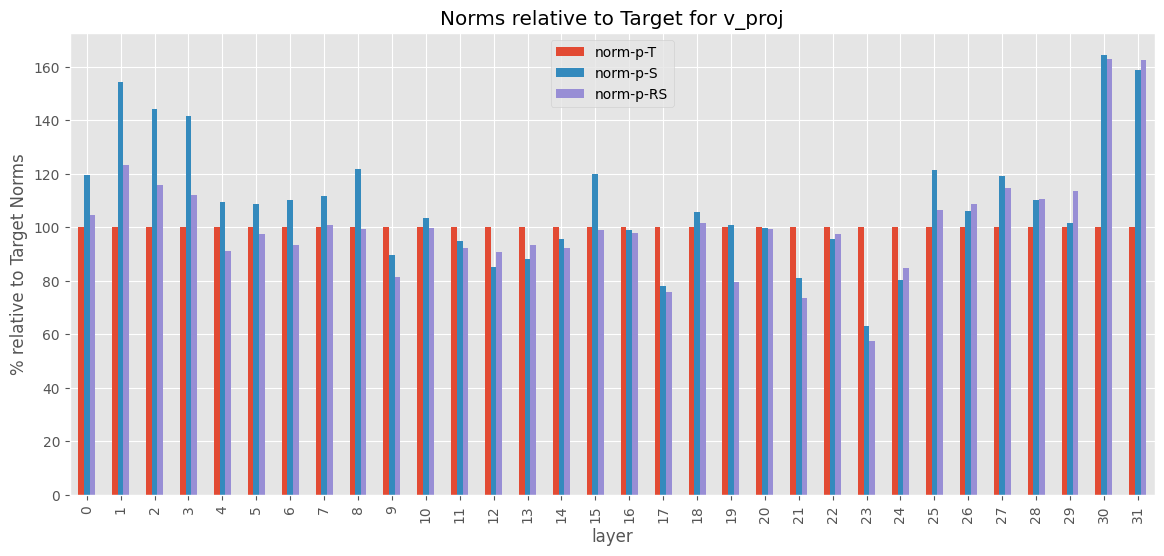

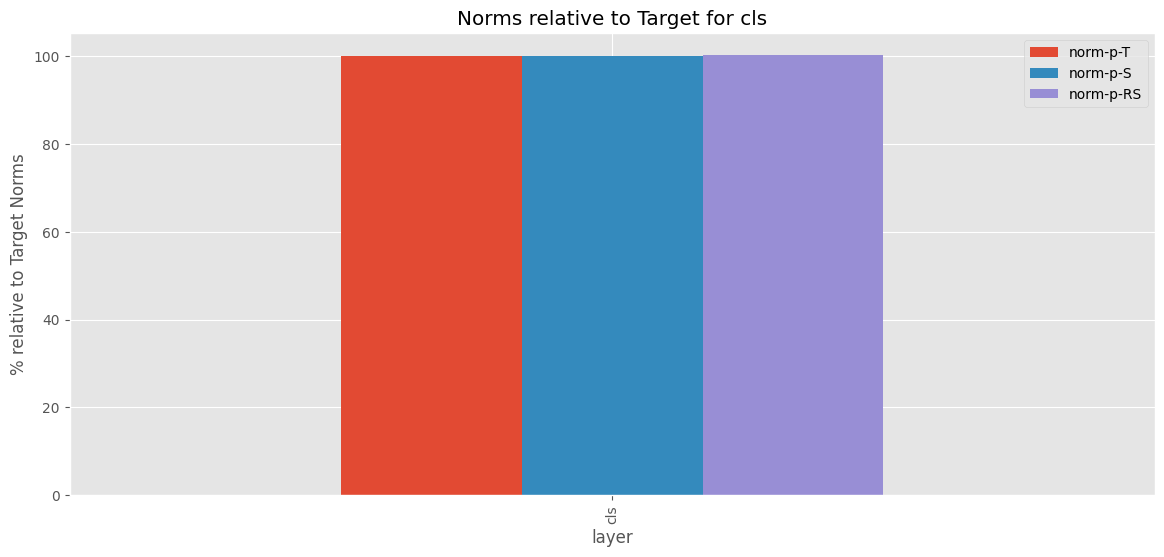

In [35]:

for k in ['q_proj','v_proj','cls']:
    fig, ax = plt.subplots(figsize=(14, 6))

    tmp = df_norms.query(f"loraProj == '{k}'").sort_values('layer').set_index('layer')[['norm-T','norm-S','norm-RS']]

    tmp['norm-p-T'] = 100

    tmp['norm-p-S'] = tmp['norm-S']/tmp['norm-T'] * 100
    tmp['norm-p-RS'] = tmp['norm-RS']/tmp['norm-T'] * 100

    tmp[['norm-p-T','norm-p-S','norm-p-RS']].plot(ax=ax, kind='bar')
    
    plt.ylabel("% relative to Target Norms")
    plt.title(f"Norms relative to Target for {k}")
    plt.show()

# Orthoganality

In [23]:
k = list(lora_merged_keys)[22]

A_t = target_tensors[f"{k}.lora_A.weight"]
B_t = target_tensors[f"{k}.lora_B.weight"]

A_s = source_tensors[f"{k}.lora_A.weight"]
B_s = source_tensors[f"{k}.lora_B.weight"]

A_rs = reverse_source_tensors[f"{k}.lora_A.weight"]
B_rs = reverse_source_tensors[f"{k}.lora_B.weight"]


# np.cross(target_tensors, source_tensors)

In [24]:
# Contribution: https://stackoverflow.com/questions/50660389/generate-a-vector-that-is-orthogonal-to-a-set-of-other-vectors-in-any-dimension

import functools

from numpy.linalg import lstsq
from scipy.linalg import orth

def find_orth(in_vectors):
    rand_vec = np.random.rand(in_vectors.shape[0], 1)
    A = np.hstack((in_vectors, rand_vec))
    b = np.zeros(in_vectors.shape[1] + 1)
    b[-1] = 1
    return lstsq(A.T, b)[0]



In [25]:

# tmpv = np.vstack([torch.matmul(B_s, A_s).flatten().numpy(), torch.matmul(B_t, A_t).flatten().numpy()])

# res = find_orth(tmpv.T)

# if all(np.abs(np.dot(res, col)) < 10e-9 for col in tmpv):
#     print("Success")
# else:
#     print("Failure")

In [26]:
tmpv = np.vstack([B_s.flatten().numpy(), B_t.flatten().numpy()])

res = find_orth(tmpv.T)

if all(np.abs(np.dot(res, col)) < 10e-9 for col in tmpv):
    print("Success")
else:
    print("Failure")

Success


/tmp/ipykernel_35242/1565682436.py:9: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  return lstsq(A.T, b)[0]


In [27]:
B_s

tensor([[-0.0020,  0.0007, -0.0018,  ..., -0.0014,  0.0018, -0.0013],
        [ 0.0036, -0.0005,  0.0017,  ...,  0.0024, -0.0025,  0.0010],
        [ 0.0041, -0.0001,  0.0015,  ...,  0.0040, -0.0031,  0.0015],
        ...,
        [-0.0018,  0.0003, -0.0021,  ...,  0.0012,  0.0005, -0.0014],
        [ 0.0004,  0.0011, -0.0011,  ...,  0.0020, -0.0001, -0.0010],
        [-0.0002, -0.0009,  0.0010,  ..., -0.0009, -0.0002,  0.0008]])

In [34]:
res

array([1.33605508e-05, 4.28886367e-05, 7.67659312e-06, ...,
       3.51797422e-05, 6.75645515e-05, 1.18948976e-06])

In [75]:
(B_rs.flatten().numpy() - np.dot(B_rs.flatten().numpy(), res)/(np.linalg.norm(res)**2)*res)[:10]

array([ 0.00248661, -0.0015905 ,  0.0005058 , -0.00280266, -0.00018802,
        0.00183417, -0.00243657,  0.00127801, -0.0021723 ,  0.00064441])

In [78]:
b_proj = np.dot(B_rs.flatten().numpy(), res)/(np.linalg.norm(res)**2)*res

In [79]:
b_proj

array([-3.69496813e-07, -1.18611985e-06, -2.12302377e-07, ...,
       -9.72924157e-07, -1.86855219e-06, -3.28962990e-08])

In [77]:
B_rs.flatten().numpy()

array([ 2.4862390e-03, -1.5916879e-03,  5.0559069e-04, ...,
       -4.4812576e-04,  2.4016370e-05,  5.1860773e-04], dtype=float32)

In [80]:
np.linalg.norm(b_proj)

0.0002639960046218577

In [82]:
np.linalg.norm(B_rs.flatten().numpy())

0.21316507

In [89]:
B_rs.shape

torch.Size([4096, 8])

In [91]:
b_proj[8:18]

array([-6.53342489e-07, -1.18201789e-06, -1.19644706e-06, -7.64503312e-07,
       -9.83106616e-07, -1.45054053e-06, -1.03219517e-06, -1.46592749e-07,
       -1.65379270e-07, -1.08402428e-07])

In [94]:
torch.tensor(b_proj.reshape(B_rs.shape)).type(torch.float32)

tensor([[-3.6950e-07, -1.1861e-06, -2.1230e-07,  ..., -1.5685e-06,
         -1.9974e-06, -7.8885e-07],
        [-6.5334e-07, -1.1820e-06, -1.1964e-06,  ..., -1.4505e-06,
         -1.0322e-06, -1.4659e-07],
        [-1.6538e-07, -1.0840e-07, -2.0754e-06,  ..., -1.7345e-07,
         -2.0488e-06, -2.4441e-06],
        ...,
        [-1.9214e-06, -1.9367e-06, -6.2182e-07,  ..., -1.9238e-06,
         -2.0849e-06, -2.4179e-07],
        [-1.4539e-06, -8.7998e-07, -7.3043e-08,  ..., -2.4500e-06,
         -1.5716e-06, -3.0376e-07],
        [-1.6106e-06, -1.8667e-07, -1.8851e-06,  ..., -9.7292e-07,
         -1.8686e-06, -3.2896e-08]])